In [1]:
import geopandas as gp
from shapely import Polygon, Point

POINT (-123.113412 49.2609022)


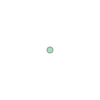

In [2]:
# city hall latitude and longitude
latitude = 49.2609022
longitude = -123.113412

# convert to point object
city_hall = Point(longitude, latitude)

# print the points longitude and latitude and plot the single point
print(city_hall)
city_hall

In [3]:
# read the file and assign the variable to the resultant geodataframe
prop_parcels = gp.read_file("data/parcels.geojson")

# combine columns into a new, single column
prop_parcels["address"] = prop_parcels["civic_number"] + " " + prop_parcels["streetname"]

# drop NaN values
prop_parcels.dropna()

# copy the desired columns into a new geodataframe in the proper order
prop_parcels = prop_parcels[["address", "tax_coord", "geometry"]]

# reproject the data to epsg 26910
prop_parcels = prop_parcels.set_crs(epsg=26910, allow_override=True)

# previewing the geodataframe to make sure our data is correct / in the proper order
prop_parcels.head(2)

,address,tax_coord,geometry
0,1483 LAMEY'S MILL ROAD,63713208,"POLYGON ((490060.168 5457445.505, 490036.068 5..."
1,1411 CARTWRIGHT ST,63513257,"POLYGON ((490133.85 5457532.499, 490133.87 545..."


In [4]:
# pass into a geoseries with Google's web mercator projection - EPSG:3857
city_hall = gp.GeoSeries(city_hall, crs=4326)


# repproject to COV's EPSG:26910
city_hall = city_hall.to_crs(epsg=26910)

city_hall

0    POINT (491748.175 5456465.887)
dtype: geometry

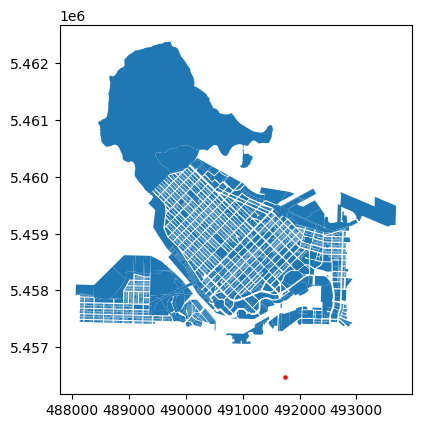

In [5]:
# set up the base map - ie. the property parcels
base = prop_parcels.plot()

# plot the city hall as a red dot using the prop_parcels as the base layers - it looks good!
city_hall.plot(ax=base, marker='o', color='red', markersize=5);

In [6]:
# we can grab the centroids of all rows like so
prop_parcels.centroid

0        POINT (490031.55 5457408.489)
1       POINT (490144.326 5457556.617)
2       POINT (490234.392 5457488.594)
3        POINT (490251.044 5457480.12)
4         POINT (490214.6 5457415.737)
                     ...              
4360    POINT (491909.518 5458733.372)
4361    POINT (492337.383 5457610.659)
4362    POINT (491108.438 5458379.314)
4363    POINT (492106.369 5458524.967)
4364     POINT (491534.209 5459674.91)
Length: 4365, dtype: geometry

In [7]:
# we can measure the distance between 1 point and city hall like so
distance = city_hall.distance(prop_parcels.centroid[0])
distance

0    1958.391691
dtype: float64

In [8]:
# how do we convert this to a column? We could
prop_parcels["distance (M)"] = []

for centroid in prop_parcels.centroid:
    prop_parcels["distance (M)"].append(city_hall.distance(centroid))

ValueError: Length of values (0) does not match length of index (4365)

In [ ]:
# how do we convert this to a column? We could try this....
import numpy as np
prop_parcels["distance (M)"] = np.nan

for centroid in prop_parcels.centroid:
    prop_parcels["distance (M)"].append(city_hall.distance(centroid))

AttributeError: 'Series' object has no attribute 'append'

In [ ]:
# we could do this in a way that sort of makes sense....
import numpy as np
prop_parcels["distance (M)"] = np.nan

for row_num in range(prop_parcels.shape[0]):
    distance = city_hall.distance(prop_parcels.centroid[row_num])
    prop_parcels.at[row_num, "distance (M)"] = distance

prop_parcels

C:\Users\rober\AppData\Local\Temp\ipykernel_23716\3359416613.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prop_parcels.at[row_num, "distance (M)"] = distance


,address,tax_coord,geometry,distance (M)
0,1483 LAMEY'S MILL ROAD,63713208,"POLYGON ((490060.168 5457445.505, 490036.068 5...",1958.391691
1,1411 CARTWRIGHT ST,63513257,"POLYGON ((490133.85 5457532.499, 490133.87 545...",1939.593201
2,1359 CARTWRIGHT ST,63513263,"POLYGON ((490232.418 5457471.56, 490232.418 54...",1826.873886
3,1325 CARTWRIGHT ST,63513279,"POLYGON ((490251.938 5457466.34, 490267.718 54...",1808.333062
4,1370 CARTWRIGHT ST,63513238,"POLYGON ((490193.917 5457373.956, 490211.617 5...",1803.903087
...,...,...,...,...
4360,250 W PENDER ST,59215604,"POLYGON ((491929.193 5458809.439, 491833.64 54...",2273.218064
4361,1610 SALT ST,18363406,"POLYGON ((492383.306 5457582.313, 492384.886 5...",1287.505065
4362,1002 SEYMOUR ST,13460602,"POLYGON ((491091.938 5458336.714, 491150.937 5...",2017.539348
4363,188 KEEFER PLACE,17259503,"POLYGON ((492056.22 5458593.043, 492052.592 54...",2090.003117


In [11]:
#thats's pretty slow, so we can switch to using list comprehension which geopandas accepts

test_list = [0,1,2,3,4]
new_list = []

for num in test_list:
    new_list.append(num * 2)

new_list

[0, 2, 4, 6, 8]

In [12]:
newer_list = [num * 2 for num in test_list]
newer_list

[0, 2, 4, 6, 8]

In [14]:
prop_parcels["distance (M)"] = [city_hall.distance(centroid) for centroid in prop_parcels.centroid]

prop_parcels

,address,tax_coord,geometry,distance (M)
0,1483 LAMEY'S MILL ROAD,63713208,"POLYGON ((490060.168 5457445.505, 490036.068 5...",0 1958.391691 dtype: float64
1,1411 CARTWRIGHT ST,63513257,"POLYGON ((490133.85 5457532.499, 490133.87 545...",0 1939.593201 dtype: float64
2,1359 CARTWRIGHT ST,63513263,"POLYGON ((490232.418 5457471.56, 490232.418 54...",0 1826.873886 dtype: float64
3,1325 CARTWRIGHT ST,63513279,"POLYGON ((490251.938 5457466.34, 490267.718 54...",0 1808.333062 dtype: float64
4,1370 CARTWRIGHT ST,63513238,"POLYGON ((490193.917 5457373.956, 490211.617 5...",0 1803.903087 dtype: float64
...,...,...,...,...
4360,250 W PENDER ST,59215604,"POLYGON ((491929.193 5458809.439, 491833.64 54...",0 2273.218064 dtype: float64
4361,1610 SALT ST,18363406,"POLYGON ((492383.306 5457582.313, 492384.886 5...",0 1287.505065 dtype: float64
4362,1002 SEYMOUR ST,13460602,"POLYGON ((491091.938 5458336.714, 491150.937 5...",0 2017.539348 dtype: float64
4363,188 KEEFER PLACE,17259503,"POLYGON ((492056.22 5458593.043, 492052.592 54...",0 2090.003117 dtype: float64


In [15]:
prop_parcels["distance (M)"] = prop_parcels["distance (M)"].astype('float')

prop_parcels

C:\Users\rober\AppData\Local\Temp\ipykernel_23716\104443369.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prop_parcels["distance (M)"] = prop_parcels["distance (M)"].astype('float')


,address,tax_coord,geometry,distance (M)
0,1483 LAMEY'S MILL ROAD,63713208,"POLYGON ((490060.168 5457445.505, 490036.068 5...",1958.391691
1,1411 CARTWRIGHT ST,63513257,"POLYGON ((490133.85 5457532.499, 490133.87 545...",1939.593201
2,1359 CARTWRIGHT ST,63513263,"POLYGON ((490232.418 5457471.56, 490232.418 54...",1826.873886
3,1325 CARTWRIGHT ST,63513279,"POLYGON ((490251.938 5457466.34, 490267.718 54...",1808.333062
4,1370 CARTWRIGHT ST,63513238,"POLYGON ((490193.917 5457373.956, 490211.617 5...",1803.903087
...,...,...,...,...
4360,250 W PENDER ST,59215604,"POLYGON ((491929.193 5458809.439, 491833.64 54...",2273.218064
4361,1610 SALT ST,18363406,"POLYGON ((492383.306 5457582.313, 492384.886 5...",1287.505065
4362,1002 SEYMOUR ST,13460602,"POLYGON ((491091.938 5458336.714, 491150.937 5...",2017.539348
4363,188 KEEFER PLACE,17259503,"POLYGON ((492056.22 5458593.043, 492052.592 54...",2090.003117


<Axes: >

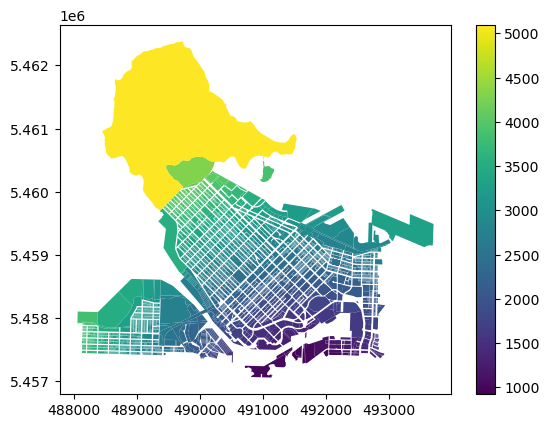

In [16]:
prop_parcels.plot('distance (M)', legend=True)

In [17]:
# import the neighbourhoods dataset
nbrhoods = gp.read_file("data/neighbourhoods.geojson")

#preview the data
nbrhoods.head(4)

,name,geo_point_2d,geometry
0,Downtown,"{ ""lon"": 491522.01866968599, ""lat"": 5458672.39...","POLYGON ((491836.34892 5459718.91871, 492419.6..."
1,Hastings-Sunrise,"{ ""lon"": 497070.97993120563, ""lat"": 5458353.91...","POLYGON ((495892.65275 5460083.76748, 496226.1..."
2,Kerrisdale,"{ ""lon"": 488380.54748552007, ""lat"": 5452331.23...","POLYGON ((486957.90955 5451434.12332, 487209.0..."
3,Marpole,"{ ""lon"": 490649.422486189, ""lat"": 5450831.9065...","POLYGON ((492208.40215 5450157.0534, 491875.55..."


In [19]:
# copy the desired columns into a new geodataframe in the proper order
nbrhoods = nbrhoods[["name", "geometry"]]

# reproject the data to epsg 26910
nbrhoods = nbrhoods.set_crs(epsg=26910, allow_override=True)

# previewing the geodataframe to make sure our data is correct / in the proper order
nbrhoods.head(5)

,name,geometry
0,Downtown,"POLYGON ((491836.349 5459718.919, 492419.675 5..."
1,Hastings-Sunrise,"POLYGON ((495892.653 5460083.767, 496226.106 5..."
2,Kerrisdale,"POLYGON ((486957.91 5451434.123, 487209.002 54..."
3,Marpole,"POLYGON ((492208.402 5450157.053, 491875.556 5..."
4,Oakridge,"POLYGON ((492310.707 5453376.091, 492269.051 5..."


<Axes: >

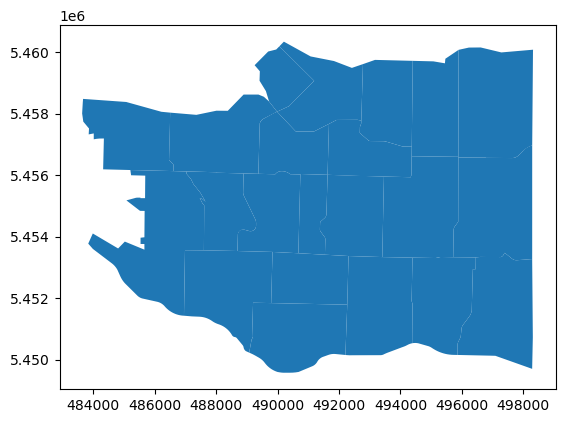

In [20]:
nbrhoods.plot()

In [22]:
# create the shorline polygon from scratch
shore_line = gp.read_file("data/shoreline.geojson")

# at this point we know we need to reproject to epsg 26910, so might as well do it right away
shore_line.set_crs(epsg=26910, allow_override=True)

shore_line

,geo_point_2d,geometry
0,"{ ""lon"": 497552.88338775164, ""lat"": 5450042.47...","LINESTRING (496830.267 5450260.3259, 496835.56..."
1,"{ ""lon"": 489112.32191897585, ""lat"": 5456580.21...","LINESTRING (498336.793 5460078.3979, 498328.63..."


In [23]:
coords = shore_line.get_coordinates()
coords

,x,y
0,496830.267,5.450260e+06
0,496835.561,5.450259e+06
0,496839.362,5.450257e+06
0,496843.077,5.450256e+06
0,496845.866,5.450255e+06
...,...,...
1,496824.878,5.450262e+06
1,496826.563,5.450261e+06
1,496828.226,5.450261e+06
1,496829.279,5.450261e+06


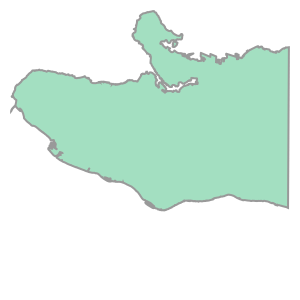

In [24]:
coords = coords.reset_index()
shore_poly = Polygon(zip(coords["x"], coords["y"]))

shore_poly

In [25]:
nbrhoods["geometry"] = nbrhoods["geometry"].intersection(shore_poly)

nbrhoods.head(3)

,name,geometry
0,Downtown,"MULTIPOLYGON (((492122.3 5459609.575, 492114.0..."
1,Hastings-Sunrise,"POLYGON ((498310.78 5460031.602, 498285.417 54..."
2,Kerrisdale,"MULTIPOLYGON (((486990.723 5453564.626, 487606..."


<Axes: >

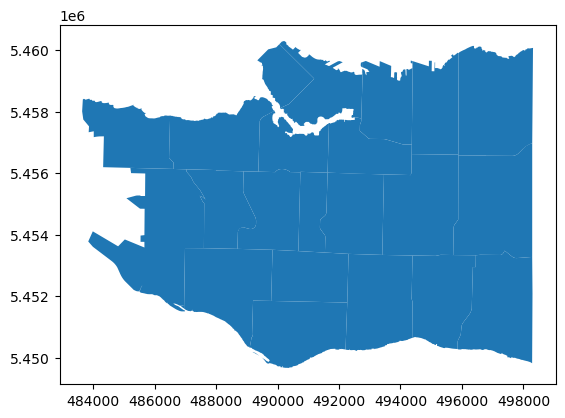

In [26]:
nbrhoods.plot()

In [27]:
nbrhoods["Area (m)"] = nbrhoods["geometry"].area

nbrhoods.head(4)

,name,geometry,Area (m)
0,Downtown,"MULTIPOLYGON (((492122.3 5459609.575, 492114.0...",3.752654e+06
1,Hastings-Sunrise,"POLYGON ((498310.78 5460031.602, 498285.417 54...",8.021899e+06
2,Kerrisdale,"MULTIPOLYGON (((486990.723 5453564.626, 487606...",6.354107e+06
3,Marpole,"MULTIPOLYGON (((489640.785 5449834.316, 489611...",5.607073e+06


In [28]:
trees = gp.read_parquet("data/trees.parquet")

trees = trees.set_crs(epsg=26910, allow_override=True)

trees.head(3)

,tree_id,civic_number,std_street,genus_name,species_name,cultivar_name,common_name,assigned,root_barrier,plant_area,...,on_street,neighbourhood_name,street_side_name,height_range_id,height_range,diameter,curb,date_planted,geom,geo_point_2d
0,903,3657,W 1ST AV,CHAMAECYPARIS,LAWSONIANA,None,LAWSON CYPRESS/PORT ORFORD CED,N,N,B,...,W 1ST AV,KITSILANO,ODD,4,40' - 50',18.0,Y,None,POINT (486558.31064 5457642.05771),POINT (486558.311 5457642.058)
1,905,625,W 53RD AV,GINKGO,BILOBA,PRINCETON SENTRY,SARATOGA GINKGO,N,N,N,...,W 53RD AV,OAKRIDGE,ODD,1,10' - 20',3.0,Y,2023-11-08,POINT (491295.53446 5452229.53355),POINT (491295.534 5452229.534)
2,910,3672,W 1ST AV,ULMUS,AMERICANA,None,AMERICAN ELM,N,N,B,...,W 1ST AV,KITSILANO,EVEN,6,60' - 70',37.0,Y,None,POINT (486529.90226 5457626.56326),POINT (486529.902 5457626.563)


In [29]:
trees.shape

(152171, 21)

In [30]:
trees.active_geometry_name

'geo_point_2d'

In [32]:
trees = trees[["geo_point_2d"]]

trees = trees.rename_geometry("tree_pts")

trees.head(4)

,tree_pts
0,POINT (486558.311 5457642.058)
1,POINT (491295.534 5452229.534)
2,POINT (486529.902 5457626.563)
3,POINT (490250.431 5452983.348)


<Axes: >

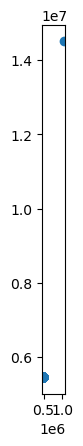

In [33]:
trees.plot()

<Axes: >

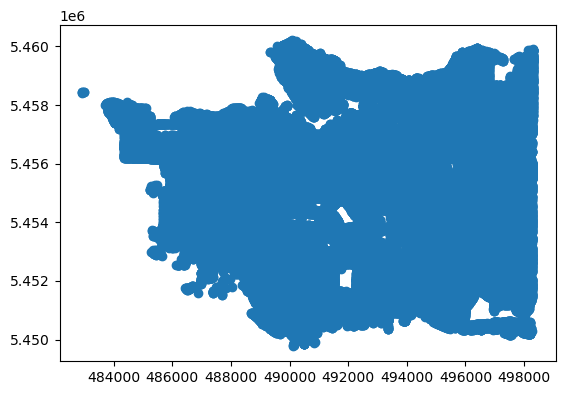

In [35]:
tree_filter = trees.within(shore_poly)

cov_trees = trees.loc[tree_filter]

cov_trees.plot()

<Axes: >

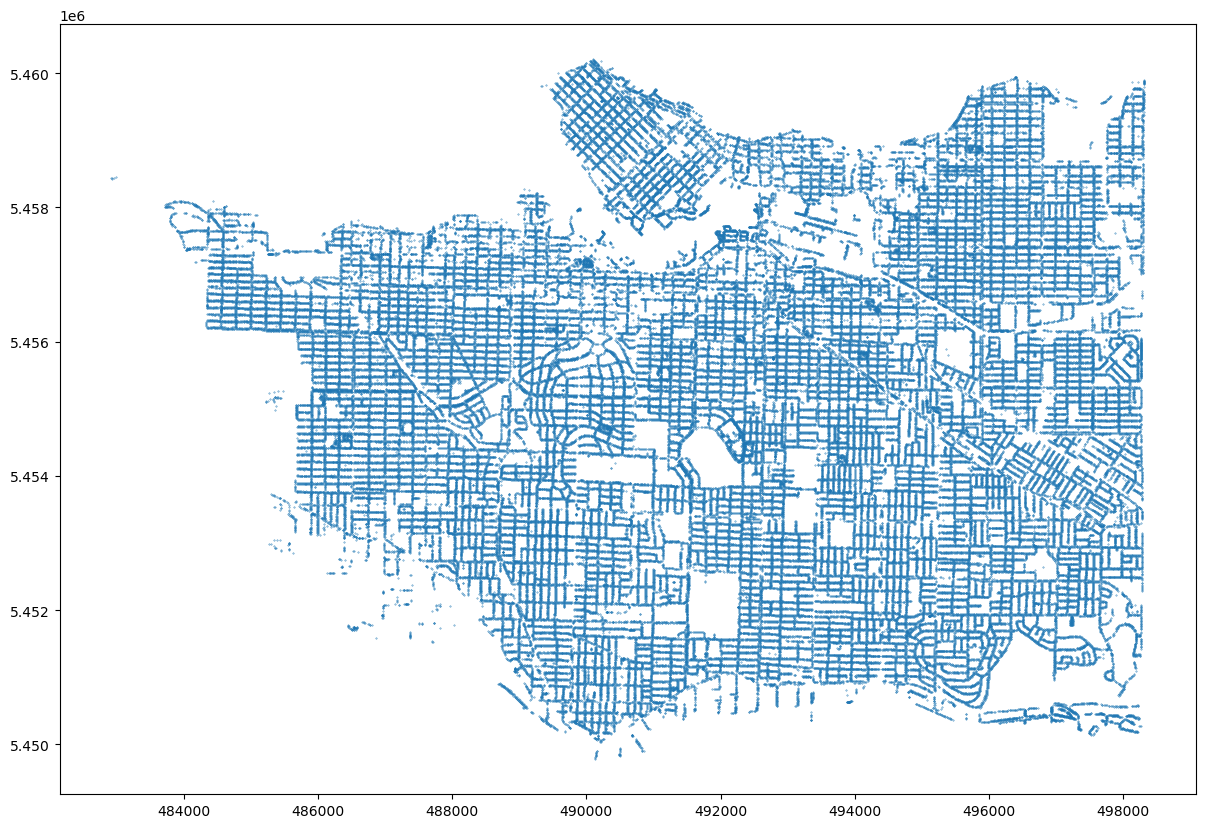

In [37]:
cov_trees.plot(markersize=0.1, figsize=(20,10))

In [38]:
nbrhd_trees = gp.sjoin(
    cov_trees,
    nbrhoods,
    how='left',
    predicate='within'
)

nbrhd_trees

,tree_pts,index_right,name,Area (m)
0,POINT (486558.311 5457642.058),18.0,Kitsilano,5.577874e+06
1,POINT (491295.534 5452229.534),4.0,Oakridge,4.023603e+06
2,POINT (486529.902 5457626.563),18.0,Kitsilano,5.577874e+06
3,POINT (490250.431 5452983.348),4.0,Oakridge,4.023603e+06
4,POINT (490261.06 5452982.774),4.0,Oakridge,4.023603e+06
...,...,...,...,...
152166,POINT (487981.765 5455538.08),14.0,Arbutus Ridge,3.700620e+06
152167,POINT (497315.105 5452005.864),17.0,Killarney,6.669148e+06
152168,POINT (497318.294 5452124.147),17.0,Killarney,6.669148e+06
152169,POINT (497327.359 5452049.103),17.0,Killarney,6.669148e+06


<Axes: >

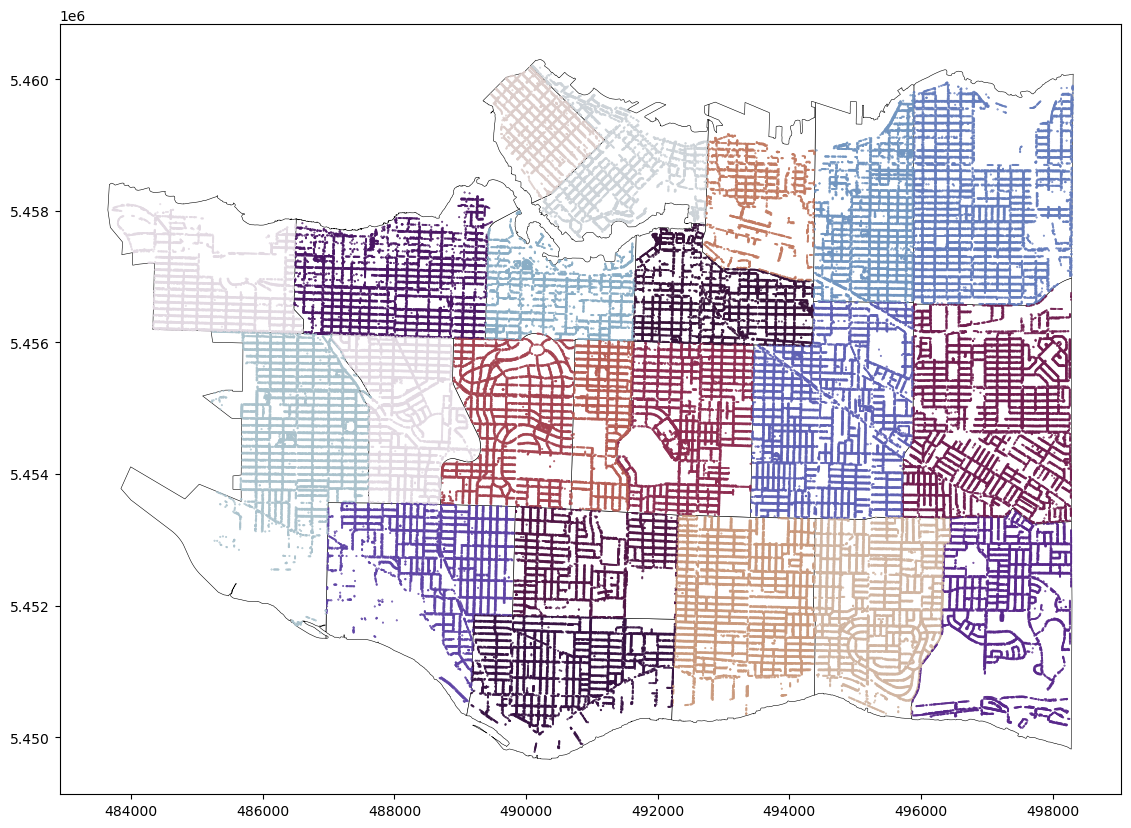

In [39]:
base = nbrhoods.plot(
    color='white',
    edgecolor='black',
    figsize=(20,10),
    linewidth=0.4
)

nbrhd_trees.plot(
    "name",
    ax=base,
    markersize=0.2,
    cmap='twilight'
)

In [40]:
trees_per_nbrhd = nbrhd_trees["name"].value_counts()

In [41]:
trees_per_nbrhd

name
Renfrew-Collingwood         11576
Kensington-Cedar Cottage    11439
Hastings-Sunrise            10219
Dunbar-Southlands            9112
Sunset                       8691
Victoria-Fraserview          8242
Kitsilano                    7989
Riley Park                   7327
Grandview-Woodland           6811
Shaughnessy                  6788
Kerrisdale                   6748
Marpole                      6559
Killarney                    6500
Mount Pleasant               6375
Arbutus Ridge                5440
West Point Grey              4841
Downtown                     4809
Oakridge                     4797
Fairview                     4141
South Cambie                 3404
West End                     3338
Strathcona                   2837
Name: count, dtype: int64

<Axes: xlabel='name'>

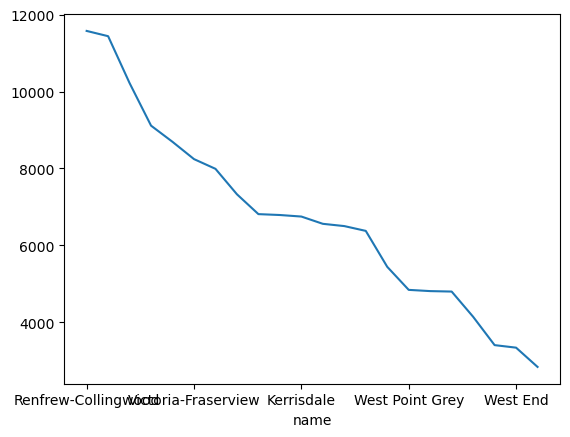

In [42]:
trees_per_nbrhd.plot()

<Axes: xlabel='name'>

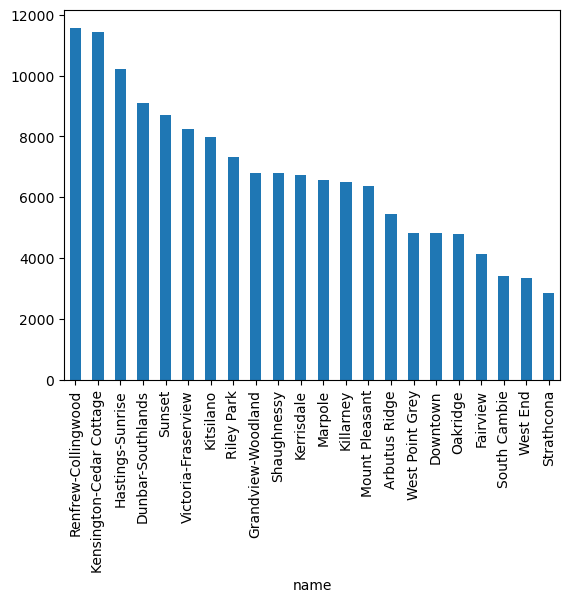

In [43]:
trees_per_nbrhd.plot.bar()

<Axes: ylabel='name'>

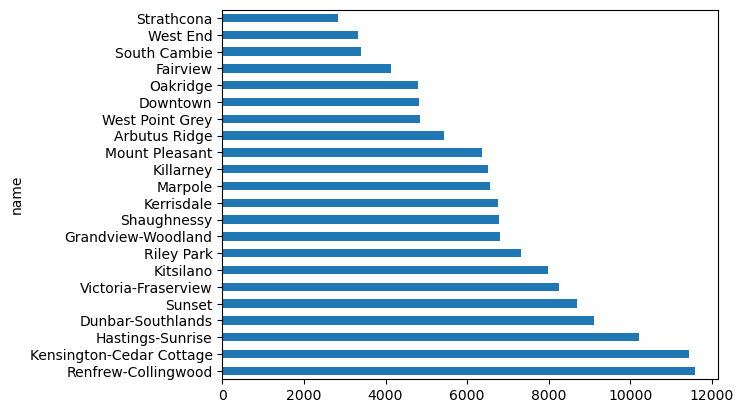

In [44]:
trees_per_nbrhd.plot.barh()

<Axes: title={'center': 'Number of Trees per Neighbourhood'}, xlabel='Number of Trees', ylabel='Vancouver Neighbourhood'>

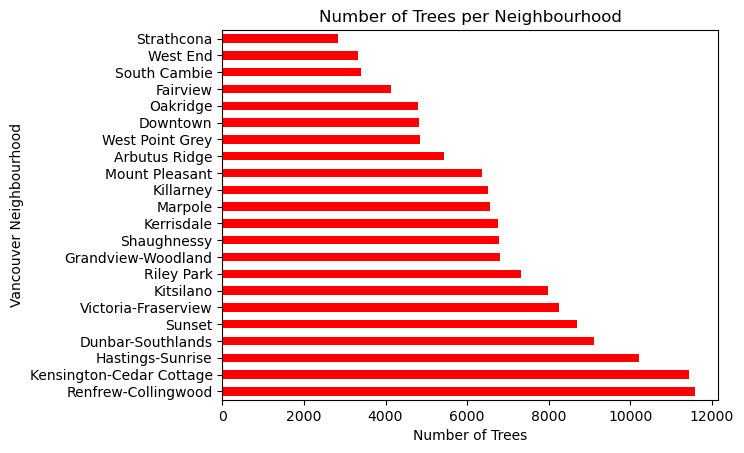

In [46]:
# ALL plotting is done by the library matplotlib. If we want to look at the arguments we can pass, we can check out the corresponding docs
trees_per_nbrhd.plot.barh(ylabel="Vancouver Neighbourhood", xlabel= "Number of Trees", title="Number of Trees per Neighbourhood", color="red")